## ==============================================================================
## 🧠 Hopify SaaS: Net Revenue Retention (NRR) vs. Gross Revenue Retention (GRR)
## ==============================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates


# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load & Clean Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "04_hopify_mrr_act_v_mrr_target_seg.csv"
)

df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Parse date & derive quarter
df['month'] = pd.to_datetime(df['month'])
df['fiscal_quarter'] = df['month'].dt.to_period('Q').astype(str)

# Filter to past 12 months
latest_month = df['month'].max()
df = df[df['month'] >= latest_month - pd.DateOffset(months=11)]

# Keep the most recent month in each quarter/segment
df = df.sort_values('month').groupby(['segment', 'fiscal_quarter'], as_index=False).tail(1)

# Segment ordering
segment_order = ["Enterprise", "Mid-Market", "SMB"]
df['segment'] = pd.Categorical(df['segment'], categories=segment_order, ordered=True)

## ==================================================
## 📊 Plot MRR vs Target by Segment
## ==================================================

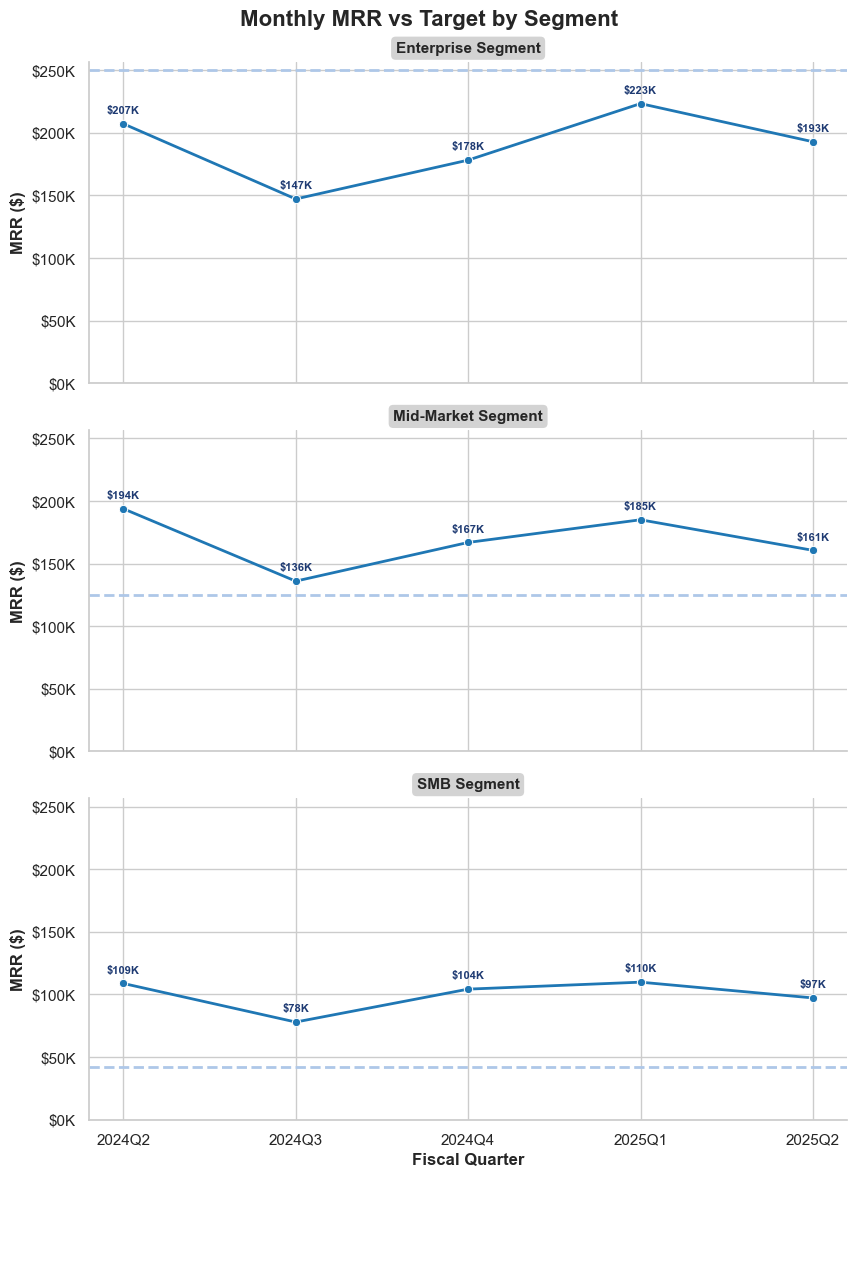

In [3]:
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df, col='segment', col_wrap=1, height=4, aspect=2, sharey=True)

g.map_dataframe(
    sns.lineplot,
    x='fiscal_quarter',
    y='mrr_actual',
    marker='o',
    color='#1f77b4',
    linewidth=2,
    label='MRR'
)

# Max Y for scaling
ymax = df['mrr_actual'].max()

for ax, segment in zip(g.axes.flat, segment_order):
    seg_df = df[df['segment'] == segment]
    target_val = seg_df['mrr_target'].iloc[0]

    # Target Line
    ax.axhline(y=target_val, linestyle='--', color='#aec7e8', linewidth=2, label='Target')

    # Format Y Axis
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
    ax.set_ylim(0, ymax * 1.15)
    ax.tick_params(axis='x', rotation=0)

    # Annotate Data Points
    for _, row in seg_df.iterrows():
        ax.text(
            row['fiscal_quarter'],
            row['mrr_actual'] + (ymax * 0.03),
            f"${row['mrr_actual']/1000:.0f}K",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='#1f3b73'
        )

    # Segment Title Header
    ax.text(
        0.5, 1.02, f"{segment} Segment",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', edgecolor='none')
    )

# Labels and Legend
g.set_axis_labels("Fiscal Quarter", "MRR ($)", fontsize=12, fontweight="bold")
g.set_titles("")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Monthly MRR vs Target by Segment", fontsize=16, fontweight="bold")

# Legend
g.add_legend(title="Metric", fontsize=9, title_fontsize=10)
g._legend.set_bbox_to_anchor((0.85, -0.05))
g._legend.set_frame_on(False)

plt.tight_layout()
plt.show()

## ================================
## 💾 Save & Show
## ================================

In [4]:

output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "02_project_revenue_profit_analysis",
    "03_hopify_mrr_vs_target_seg.png"
)

plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Chart saved to: {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Chart saved to: /Users/jade.herman/Documents/00_github/hopify_saas_kpi_analysis/05_visuals/02_project_revenue_profit_analysis/03_hopify_mrr_vs_target_seg.png
